In [56]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from mpl_chord_diagram import chord_diagram

load_dotenv()

True

In [57]:
LANGUAGE = "en"
ZONE = "GUY+Georgetown"

In [58]:
data_path = Path(os.environ["DATA_PATH"])
ghsl_path = Path(os.environ["GHSL_PATH"])
out_path = data_path / "generated"

figure_path: Path = Path("./fig") / LANGUAGE / ZONE
figure_path.mkdir(parents=True, exist_ok=True)

In [59]:
df_bbox = gpd.read_file(out_path / "small" / "bbox" / "shapely" / f"{ZONE}.gpkg")

In [60]:
_color_map_base = {
    "croplands": "#B8860B",
    "flooded": "#4169E1",
    "forests_primary": "#006400",
    "forests_secondary": "#228B22",
    "forests_mangroves": "#00FF7F",
    "grasslands": "#90EE90",
    "other": "#9932CC",
    "pastures": "#FFD700",
    "settlements": "#808080",
    "shrublands": "#FFA07A",
    "wetlands": "#40E0D0",
}

if LANGUAGE == "en":
    COLUMN_NAME_MAP = {
        "croplands": "Croplands",
        "flooded": "Flooded",
        "forests_primary": "Primary forests",
        "forests_secondary": "Secondary forests",
        "forests_mangroves": "Mangroves",
        "grasslands": "Grasslands",
        "other": "Other",
        "pastures": "Pastures",
        "settlements": "Settlements",
        "shrublands": "Shrublands",
        "wetlands": "Wetlands",
    }
elif LANGUAGE == "es":
    COLUMN_NAME_MAP = {
        "croplands": "Cultivos",
        "flooded": "Inundado",
        "forests_primary": "Bosques primarios",
        "forests_secondary": "Bosques secundarios",
        "forests_mangroves": "Manglares",
        "grasslands": "Pastizales",
        "other": "Otro",
        "pastures": "Pastizales\np/ganado",
        "settlements": "Asentamientos",
        "shrublands": "Matorrales",
        "wetlands": "Humedales",
    }
else:
    raise ValueError("Language not supported")


COLUMN_COLOR_MAP = {
    COLUMN_NAME_MAP[key]: _color_map_base[key] for key in COLUMN_NAME_MAP.keys()
}
COLUMN_COLOR_MAP["Total"] = "#000000"

# Area

In [61]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .T.reset_index(names="year")
    .assign(year=lambda df: (df["year"].astype(int) + 2000))
    .query("2000 <= year <= 2020")
    .assign(year=lambda df: df["year"].astype(str))
    .set_index("year")
    .divide(100)
    .rename(columns=COLUMN_NAME_MAP)
)

masked = (df_area.div(df_area.sum(axis=1), axis=0) < 0.01).all(axis=0)
masked_cols = masked[~masked].index

<Axes: xlabel='year'>

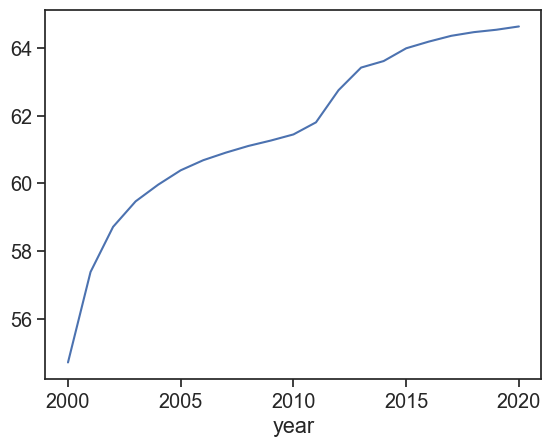

In [62]:
df_area["Settlements"].plot()

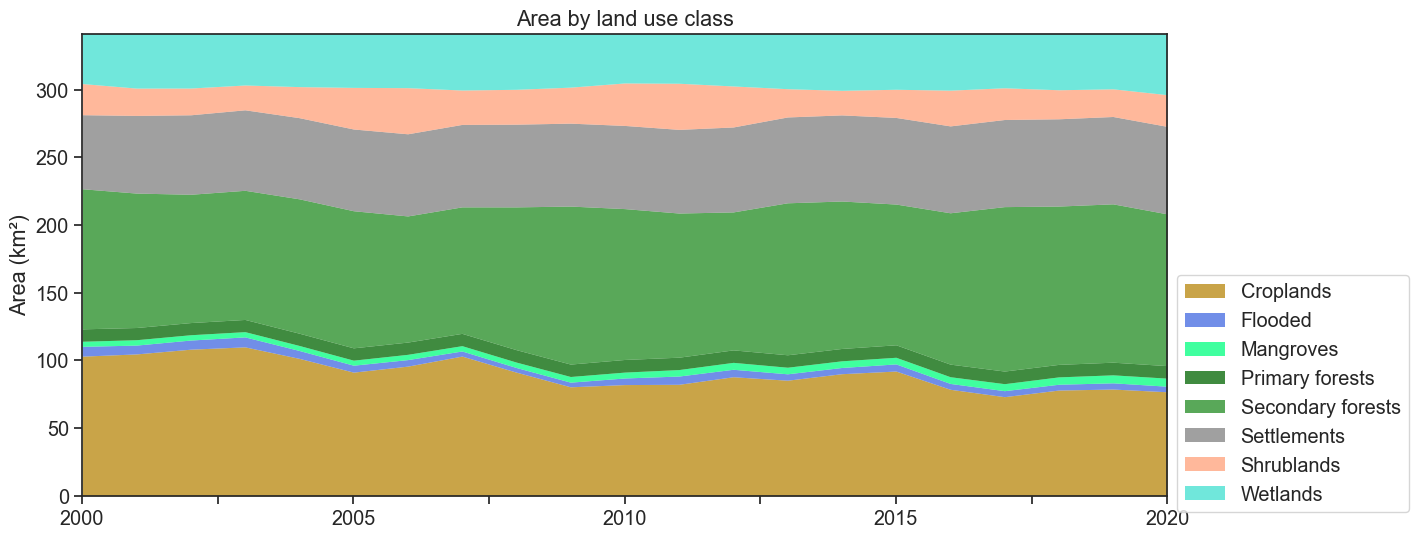

In [63]:
sns.set_theme(style="ticks", font_scale=1.3)

fig, ax = plt.subplots(figsize=(14, 6))
df_area[masked_cols].plot.area(ax=ax, color=COLUMN_COLOR_MAP, alpha=0.75, lw=0)
ax.legend(bbox_to_anchor=(1, 0.5))

ax.set_xlim(0, 20)
ax.set_ylim(0, df_area.sum(axis=1).max() * 0.97)

if LANGUAGE == "en":
    ax.set_ylabel("Area (km²)")
elif LANGUAGE == "es":
    ax.set_ylabel("Área (km²)")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

if LANGUAGE == "en":
    ax.set_title("Area by land use class")
elif LANGUAGE == "es":
    ax.set_title("Área por clase de uso de suelo")
else:
    raise ValueError("Language not supported")

fig.savefig(figure_path / "area.jpg", bbox_inches="tight", dpi=200)

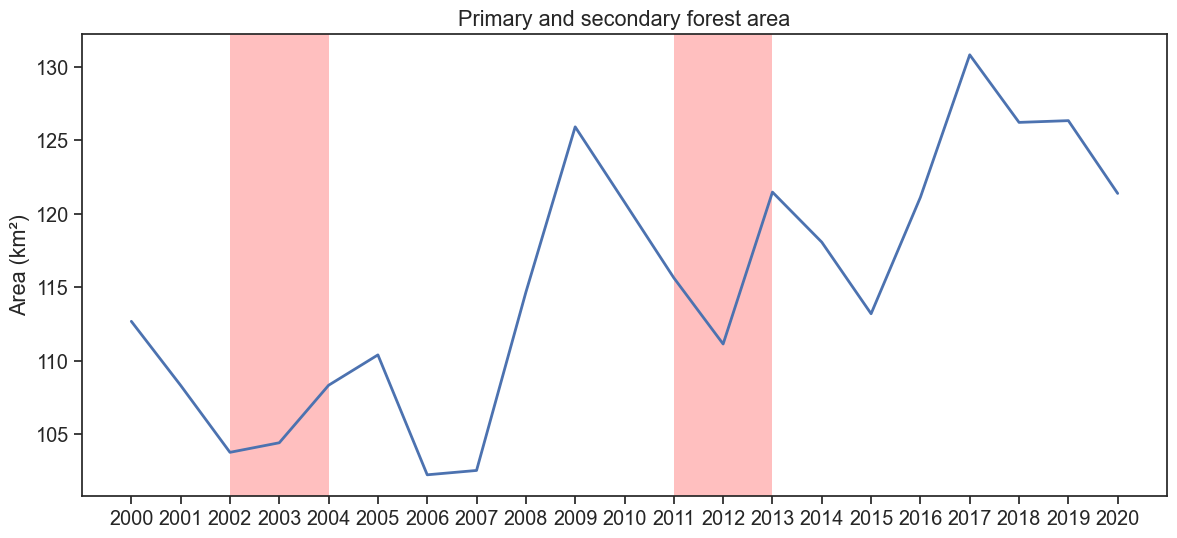

In [64]:
sns.set_theme(style="ticks", font_scale=1.3)

if LANGUAGE == "en":
    wanted_cols = ["Primary forests", "Secondary forests"]
elif LANGUAGE == "es":
    wanted_cols = ["Bosques primarios", "Bosques secundarios"]
else:
    raise ValueError("Language not supported")

df_temp = (
    df_area.filter(wanted_cols, axis=1)
    .filter([str(year) for year in range(2000, 2021)], axis=0)
    .sum(axis=1)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(df_temp, ax=ax, lw=2, c="C0")
ax.axvspan("2002", "2004", color="red", alpha=0.25, ec="none")
ax.axvspan("2011", "2013", color="red", alpha=0.25, ec="none")

if LANGUAGE == "en":
    ax.set_ylabel("Area (km²)")
    ax.set_title("Primary and secondary forest area")
elif LANGUAGE == "es":
    ax.set_ylabel("Área (km²)")
    ax.set_title("Área de bosques primarios y secundarios")
else:
    raise ValueError("Language not supported")

fig.savefig(figure_path / "area_forest.jpg", bbox_inches="tight", dpi=200)

# Area transitions

## Circle

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\mpl_chord_diagram\utilities.py:167: RuntimeWarning: invalid value encountered in divide
  return (mat[i, :] / x[i]) * (end - start)


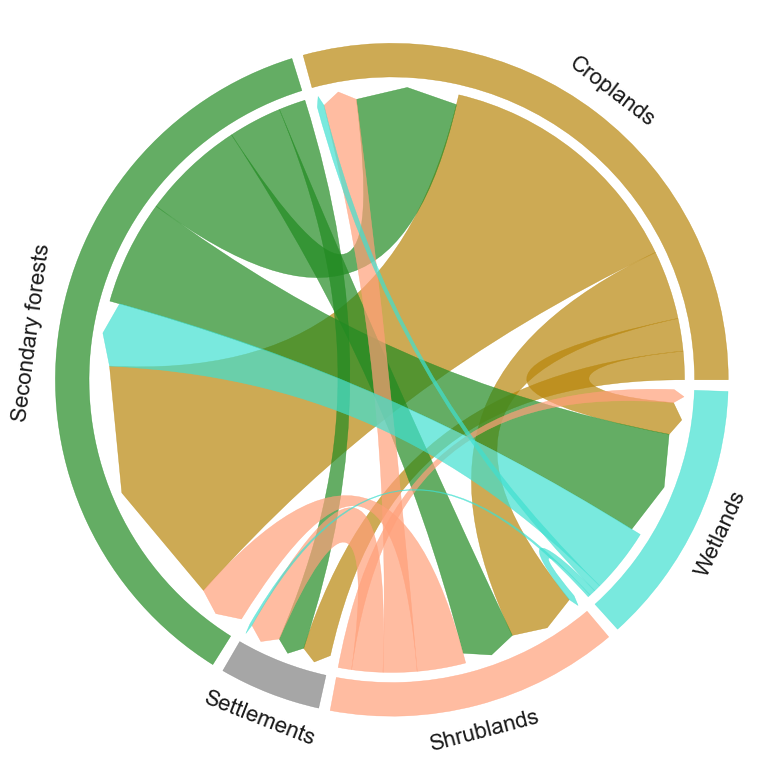

In [65]:
pivot = (
    pd.read_csv(
        out_path
        / "small"
        / "transition"
        / "table_fixed_extra"
        / "2000_2020"
        / f"{ZONE}.csv",
    )
    .set_index("start")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

mask = (pivot.sum(axis=0) > 10 * 1e6) & (pivot.sum(axis=1) > 10 * 1e6)
wanted_idx = mask[mask].index

pivot = pivot.filter(wanted_idx, axis=0).filter(wanted_idx, axis=1)

names = [COLUMN_NAME_MAP[c] for c in pivot.index]

mat = pivot.to_numpy()
np.fill_diagonal(mat, 0)

if ZONE == "MEX+Monterrey":
    rotate_names = [False, False, False, True, True, True, False, False]
elif ZONE == "PER+Maynas":
    rotate_names = [True, False, False, True, True, True, False]
else:
    rotate_names = [False] * len(names)

fig, ax = plt.subplots(figsize=(8, 8))
diag = chord_diagram(
    mat,
    ax=ax,
    names=names,
    directed=True,
    rotate_names=rotate_names,
    colors=[COLUMN_COLOR_MAP[c] for c in names],
    fontsize=16,
)
fig.savefig(figure_path / "chord_bidirectional.jpg", bbox_inches="tight", dpi=200)

# Emissions

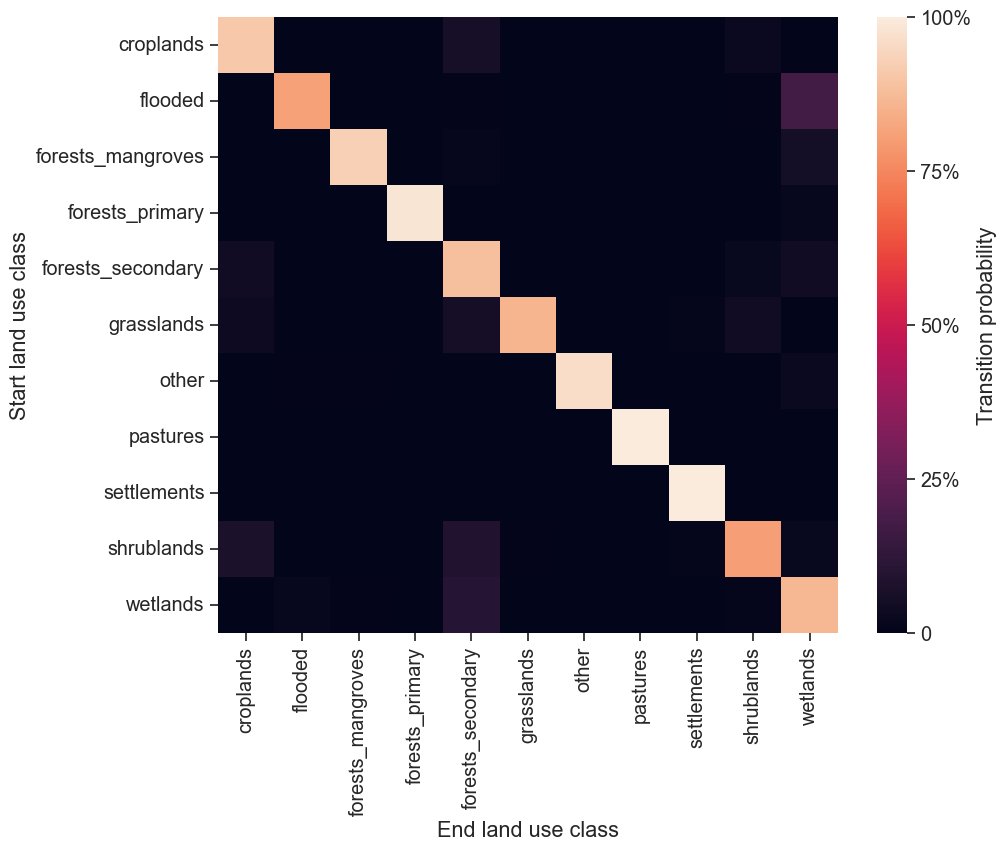

In [66]:
df_cube = (
    pd.read_csv(out_path / "small" / "transition" / "cube" / f"{ZONE}.csv")
    .melt(id_vars="time_period")
    .assign(
        start=lambda df: df["variable"]
        .str.split("_to_")
        .str[0]
        .str.replace("pij_lndu_", ""),
        end=lambda df: df["variable"].str.split("_to_").str[1],
    )
    .drop(columns=["variable"])
    .pivot_table(index="start", columns="end", values="value")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_cube, ax=ax)
ax.set_xlabel("End land use class")
ax.set_ylabel("Start land use class")
cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(["0", "25%", "50%", "75%", "100%"])
cbar.set_label("Transition probability")

fig.savefig(figure_path / "transition_heatmap.jpg", bbox_inches="tight", dpi=200)

In [67]:
df_out = pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv").query(
    "time_period < 21",
)

In [68]:
df_out[[c for c in df_out.columns if "sequestration" in c]]

,emission_co2e_co2_lndu_biomass_sequestration_grasslands,emission_co2e_co2_lndu_biomass_sequestration_other,emission_co2e_co2_lndu_biomass_sequestration_pastures,emission_co2e_co2_lndu_biomass_sequestration_settlements,emission_co2e_co2_lndu_biomass_sequestration_shrublands,emission_co2e_co2_lndu_biomass_sequestration_wetlands,emission_co2e_co2_frst_sequestration_mangroves,emission_co2e_co2_frst_sequestration_primary,emission_co2e_co2_frst_sequestration_secondary
0,-0.0,-0.0,-0.0,-0.0,-0.002408,-0.0,-0.001001,-0.000771,-0.027256
1,-0.0,-0.0,-0.0,-0.0,-0.001959,-0.0,-0.001021,-0.000771,-0.028430
2,-0.0,-0.0,-0.0,-0.0,-0.001760,-0.0,-0.001021,-0.000771,-0.028351
3,-0.0,-0.0,-0.0,-0.0,-0.001552,-0.0,-0.001024,-0.000771,-0.028919
4,-0.0,-0.0,-0.0,-0.0,-0.002027,-0.0,-0.001037,-0.000771,-0.029593
5,-0.0,-0.0,-0.0,-0.0,-0.002935,-0.0,-0.001069,-0.000771,-0.029517
6,-0.0,-0.0,-0.0,-0.0,-0.003141,-0.0,-0.001088,-0.000771,-0.027935
7,-0.0,-0.0,-0.0,-0.0,-0.002270,-0.0,-0.001088,-0.000771,-0.028711
8,-0.0,-0.0,-0.0,-0.0,-0.002382,-0.0,-0.001123,-0.000771,-0.031275
9,-0.0,-0.0,-0.0,-0.0,-0.002552,-0.0,-0.001199,-0.000771,-0.033616


In [69]:
(
    df_out["emission_co2e_co2_frst_sequestration_primary"]
    + df_out["emission_co2e_co2_frst_sequestration_secondary"]
    + df_out["emission_co2e_ch4_frst_methane_primary"]
    + df_out["emission_co2e_ch4_frst_methane_secondary"]
    + df_out["emission_co2e_co2_frst_forest_fires"]
)

0    -0.027711
1    -0.028873
2    -0.028794
3    -0.029357
4    -0.030024
5    -0.029948
6    -0.028383
7    -0.029150
8    -0.031687
9    -0.034003
10   -0.031990
11   -0.030224
12   -0.029599
13   -0.031790
14   -0.030568
15   -0.029038
16   -0.030889
17   -0.033206
18   -0.031830
19   -0.031695
20   -0.030286
dtype: float64

In [70]:
df_out["emission_co2e_subsector_total_frst"]

0    -0.028702
1    -0.029883
2    -0.029805
3    -0.030370
4    -0.031050
5    -0.031006
6    -0.029459
7    -0.030227
8    -0.032798
9    -0.035189
10   -0.033260
11   -0.031613
12   -0.031054
13   -0.033324
14   -0.032200
15   -0.030738
16   -0.032690
17   -0.035138
18   -0.033919
19   -0.034019
20   -0.032816
Name: emission_co2e_subsector_total_frst, dtype: float64

In [71]:
wanted_cols = [
    "emission_co2e_subsector_total_frst",
    "emission_co2e_subsector_total_lndu",
    "emission_co2e_co2_soil_soc_mineral_soils",
    "emission_co2e_n2o_soil_mineral_soils",
    "emission_co2e_n2o_soil_organic_soils",
    "time_period",
]

if LANGUAGE == "en":
    name_map = {
        "emission_co2e_subsector_total_frst": "Forests",
        "emission_co2e_subsector_total_lndu": "Land use transitions",
        "emission_co2e_co2_soil_soc_mineral_soils": "Soil mineralization",
        "emission_co2e_n2o_soil_mineral_soils": "Soil mineralization (N2O equiv.)",
        "emission_co2e_n2o_soil_organic_soils": "Organic soil (N2O equiv.)",
    }
elif LANGUAGE == "es":
    name_map = {
        "emission_co2e_subsector_total_frst": "Bosques",
        "emission_co2e_subsector_total_lndu": "Transiciones de uso de suelo",
        "emission_co2e_co2_soil_soc_mineral_soils": "Mineralización del suelo",
        "emission_co2e_n2o_soil_mineral_soils": "Mineralización del suelo\n(equivalente N2O)",
        "emission_co2e_n2o_soil_organic_soils": "Suelo orgánico\n(equivalente N2O)",
    }
else:
    raise ValueError("Language not supported")

df_plot = (
    df_out[wanted_cols]
    .rename(columns=name_map)
    .assign(time_period=lambda df: (df["time_period"] + 2000))
    .set_index("time_period")
)

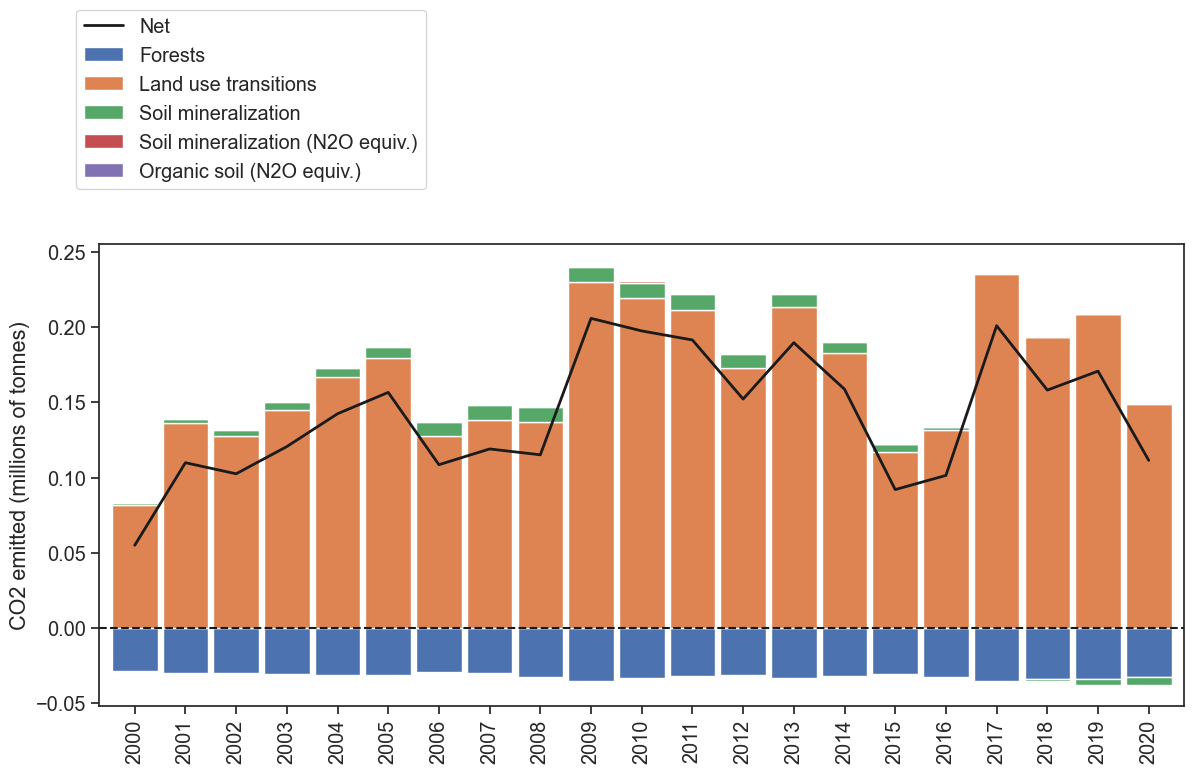

In [72]:
sns.set_theme(style="ticks", font_scale=1.3)

fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot.bar(stacked=True, ax=ax, width=0.9, legend=False)

if LANGUAGE == "en":
    label = "Net"
elif LANGUAGE == "es":
    label = "Neto"
else:
    raise ValueError("Language not supported")

df_plot.sum(axis=1).reset_index().assign(
    time_period=lambda df: df["time_period"].astype(str),
).set_index("time_period")[0].plot(ax=ax, c="k", label=label, lw=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.axhline(0, 0, 1, c="k", ls="--")

ax.set_xlabel(None)

if LANGUAGE == "en":
    ax.set_ylabel("CO2 emitted (millions of tonnes)")
elif LANGUAGE == "es":
    ax.set_ylabel("CO2 emitido (millones de toneladas)")
else:
    raise ValueError("Language not supported")

ax.legend(bbox_to_anchor=(0.31, 1.53))
fig.savefig(figure_path / "carbon.jpg", bbox_inches="tight", dpi=200)

# Emissions by transition

In [73]:
def prettify_column(c: str, pretty_labels: bool) -> str:
    if c == "year":
        return c

    c = c.replace("emission_co2e_co2_lndu_conversion_", "")
    start, end = c.split("_to_")
    if pretty_labels:
        return f"{COLUMN_NAME_MAP[start]}-{COLUMN_NAME_MAP[end]}"
    return f"{start}-{end}"

In [75]:
df_transitions = (
    pd.read_csv(out_path / "small" / "transitions_emissions" / f"{ZONE}.csv")
    .assign(time_period=lambda df: (df["time_period"] + 2000))
    .query("2000 <= time_period <= 2020")
    .assign(time_period=lambda df: df["time_period"].astype(str))
    .set_index("time_period")
)
df_transitions.columns = [
    prettify_column(c, pretty_labels=True) for c in df_transitions.columns
]

3061.904242468485


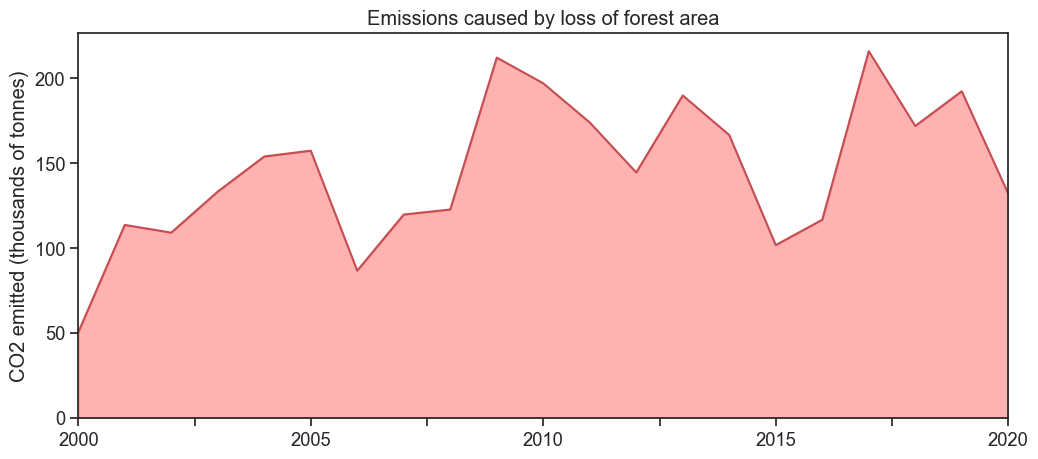

In [76]:
sns.set_theme(font_scale=1.2, style="ticks")

if LANGUAGE == "en":
    df_temp = (
        df_transitions[[c for c in df_transitions.columns if "forests" in c.casefold()]]
        .sum(axis=1)
        .multiply(1000)
    )
elif LANGUAGE == "es":
    df_temp = (
        df_transitions[[c for c in df_transitions.columns if c.startswith("Bosques")]]
        .sum(axis=1)
        .multiply(1000)
    )
else:
    raise ValueError("Language not supported")

fig, ax = plt.subplots(figsize=(12, 5))
df_temp.plot(ax=ax, c="r")
print(df_temp.sum())

if LANGUAGE == "en":
    ax.set_title("Emissions caused by loss of forest area")
    ax.set_ylabel("CO2 emitted (thousands of tonnes)")
elif LANGUAGE == "es":
    ax.set_title("Emisiones causadas por la pérdida de área forestal")
    ax.set_ylabel("CO2 emitido (miles de toneladas)")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)
ax.fill_between(df_temp.index, df_temp, alpha=0.3, color="red")

ax.set_xlim("2000", "2020")
ax.set_ylim(0, ax.get_ylim()[1])

fig.savefig(figure_path / "emissions_from_forest.jpg", bbox_inches="tight", dpi=200)

In [77]:
df_temp = (
    df_transitions.reset_index()
    .melt(id_vars="time_period")
    .assign(
        start=lambda df: df["variable"].str.split("-").str[0],
        end=lambda df: df["variable"].str.split("-").str[1],
    )
    .drop(columns="variable")
    .groupby(["time_period", "end"])["value"]
    .sum()
    .reset_index()
    .pivot_table(index="time_period", columns="end", values="value")
)

if LANGUAGE == "en":
    df_temp = df_temp.filter(["Croplands", "Pastures", "Settlements"])
elif LANGUAGE == "es":
    df_temp = df_temp.filter(["Cultivos", "Pastizales p/ganado", "Asentamientos"])
else:
    raise ValueError("Language not supported")

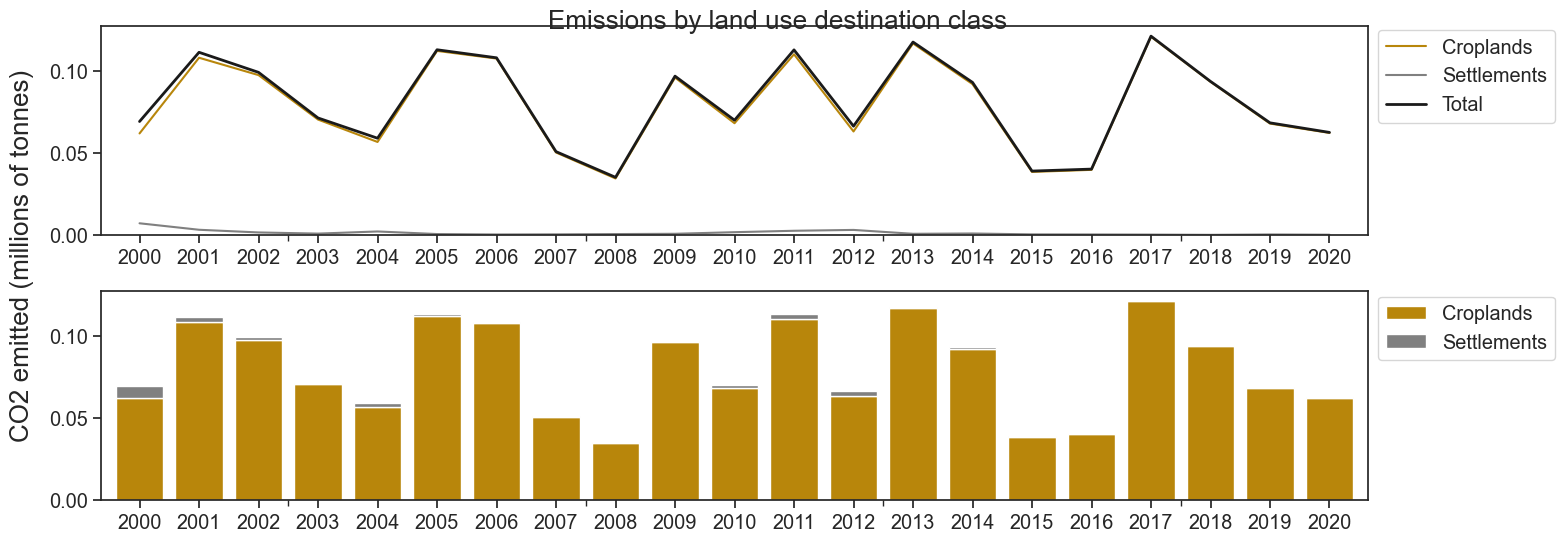

In [78]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

df_temp.plot(ax=ax1, legend=True, color=COLUMN_COLOR_MAP)
df_temp.sum(axis=1).plot(ax=ax1, c="k", lw="2", label="Total")

df_temp.plot.bar(ax=ax2, stacked=True, width=0.8, rot=0, color=COLUMN_COLOR_MAP)

ax1.set_ylim(*ax2.get_ylim())
ax1.set_xlabel(None)
ax1.xaxis.set_tick_params(labelbottom=True)
ax1.legend(bbox_to_anchor=(1, 0.76), loc="center left")

ax2.set_xlabel(None)
ax2.legend(bbox_to_anchor=(1, 0.82), loc="center left")

if LANGUAGE == "en":
    fig.supylabel("CO2 emitted (millions of tonnes)")
    fig.suptitle("Emissions by land use destination class", y=0.91)
elif LANGUAGE == "es":
    fig.supylabel("CO2 emitido (millones de toneladas)")
    fig.suptitle("Emisiones por clase de destino de uso de suelo", y=0.94)
else:
    raise ValueError("Language not supported")

fig.tight_layout()
fig.savefig(figure_path / "emissions_by_end.jpg", bbox_inches="tight", dpi=200)

1.7012693070139457


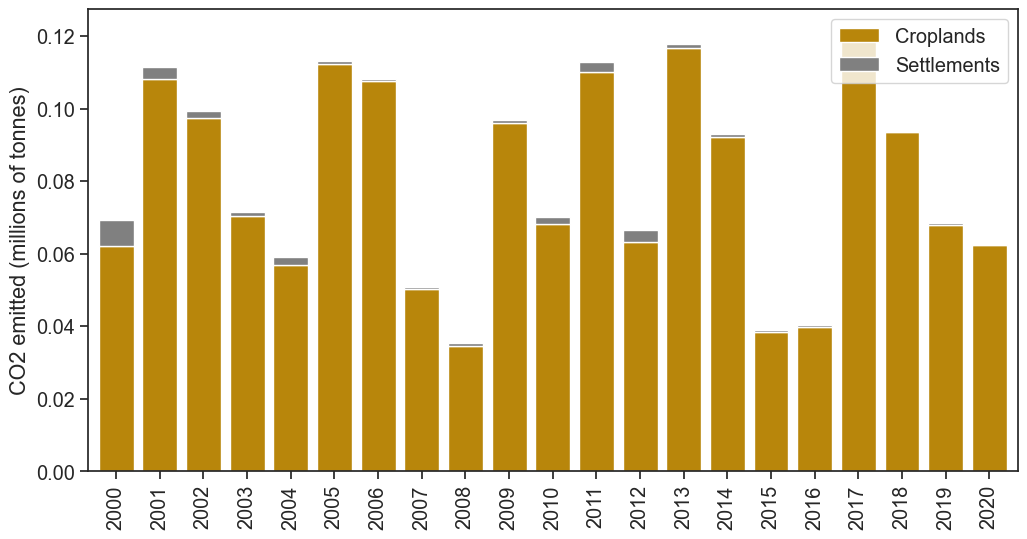

In [79]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, ax = plt.subplots(figsize=(12, 6))
df_temp.plot.bar(ax=ax, stacked=True, width=0.8, rot=0, color=COLUMN_COLOR_MAP)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlabel(None)

print(df_temp.sum().sum())

if LANGUAGE == "en":
    ax.set_ylabel("CO2 emitted (millions of tonnes)")
elif LANGUAGE == "es":
    ax.set_ylabel("CO2 emitido (millones de toneladas)")
else:
    raise ValueError("Language not supported")

In [88]:
df_temp = (
    df_transitions.reset_index()
    .melt(id_vars="time_period")
    .assign(
        start=lambda df: df["variable"].str.split("-").str[0],
        end=lambda df: df["variable"].str.split("-").str[1],
    )
    .drop(columns="variable")
    .groupby(["time_period", "end"])["value"]
    .sum()
    .reset_index()
    .pivot_table(index="time_period", columns="end", values="value")
    .multiply(1000)
)

# if LANGUAGE == "en":
#     df_temp = df_temp.filter(["Settlements"])
# elif LANGUAGE == "es":
#     df_temp = df_temp.filter(["Asentamientos"])
# else:
#     raise ValueError("Language not supported")

ValueError: 'x' has size 21, but 'y1' has an unequal size of 147

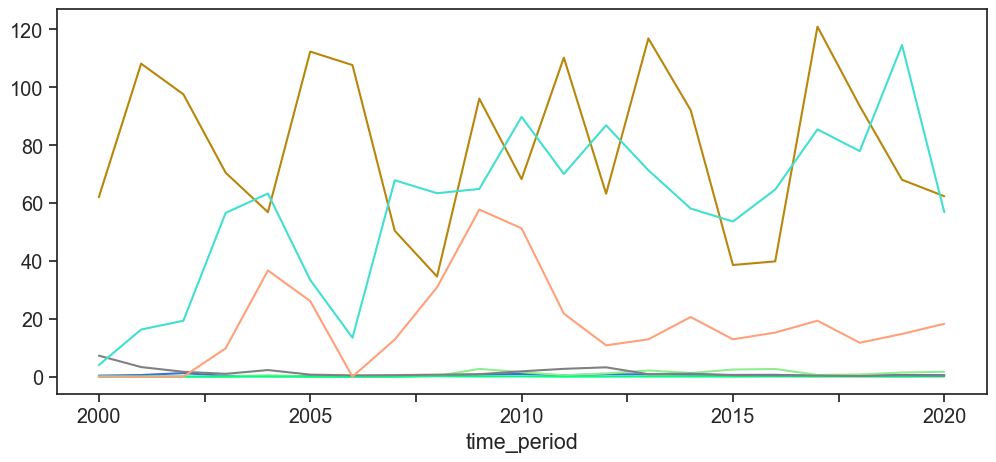

In [ ]:
sns.set_theme(font_scale=1.3, style="ticks")

fig, ax = plt.subplots(figsize=(12, 5), sharex=True)

df_temp.plot(ax=ax, legend=False, color=COLUMN_COLOR_MAP)
print(df_temp.sum().item())

if LANGUAGE == "en":
    ax.fill_between(
        df_temp.index,
        df_temp.values.flatten(),
        alpha=0.3,
        color=COLUMN_COLOR_MAP["Settlements"],
    )
    ax.set_ylabel("CO2 emitted (thousands of tonnes)")
    ax.set_title("Settlement destination emissions")
elif LANGUAGE == "es":
    ax.fill_between(
        df_temp.index,
        df_temp.values.flatten(),
        alpha=0.3,
        color=COLUMN_COLOR_MAP["Asentamientos"],
    )
    ax.set_ylabel("CO2 emitido (miles de toneladas)")
    ax.set_title("Emisiones producidas por urbanización")
else:
    raise ValueError("Language not supported")

ax.set_xlabel(None)

ax.set_xlim("2000", "2020")
ax.set_ylim(0, ax.get_ylim()[1])

fig.tight_layout()
fig.savefig(figure_path / "emissions_by_urb.jpg", bbox_inches="tight", dpi=200)

In [ ]:
corr = pd.concat(
    [df_area["Settlements"].rename("area"), df_temp["Settlements"].rename("emissions")],
    axis=1,
)

<Axes: xlabel='area', ylabel='emissions'>

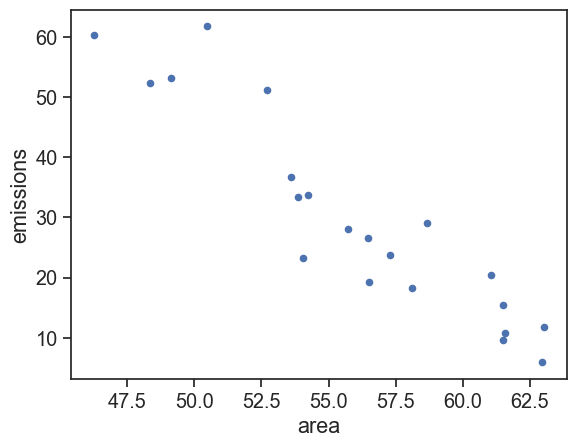

In [ ]:
corr.plot.scatter(x="area", y="emissions")